## Submission 3. Figure - SWR Remote Content

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pickle
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import ranksums
from spyglass.shijiegu.Analysis_SGU import ChangeofMind, ChangeofMindRemoteSWR, ChangeofMindRemoteTheta

[2026-01-14 11:46:53,543][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [5]:
list_of_days_animals = {}
success_animal = {}

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']

animal = 'lewis'
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']

### Overall number of trials with change of mind considered

In [6]:
com_info_animals = {}

for animal in ["molly","eliot","julio","klein","lewis"]:
    info_all = []
    dates_to_plot = list_of_days_animals[animal]

    for day in dates_to_plot:
        nwb_copy_file_name = animal.lower() + day + '_.nwb'
        queries = (ChangeofMind() & {"nwb_file_name": nwb_copy_file_name, "proportion": "0.1"}).fetch(as_dict = True)
        for query in queries:
            log_df = pd.DataFrame(query["pandas"])
            log_df = log_df[log_df.change_of_mind]
            if len(log_df) == 0:
                continue
            for trialID in log_df.index:
                info_all.append((nwb_copy_file_name, query["epoch"], trialID))
                
    com_info_animals[animal] = info_all

### Remote content during SWR

In [8]:
swr_info_animals = {}

for animal in ["molly","eliot","julio","klein","lewis"]:
    info_all = []
    dates_to_plot = list_of_days_animals[animal]

    for day in dates_to_plot:
        nwb_copy_file_name = animal.lower() + day + '_.nwb'
        queries = (ChangeofMindRemoteSWR() & {"nwb_file_name": nwb_copy_file_name, "parameter_name": "2state_10_cm"}).fetch(as_dict = True)
        for query in queries:
            log_df_swr = pd.DataFrame(query["pandas"])
            log_df_swr_remote = log_df_swr[log_df_swr.has_remote_interval]
            if len(log_df_swr_remote) == 0:
                continue
            for trialID in log_df_swr_remote.index:
                info_all.append((nwb_copy_file_name, query["epoch"], trialID))
                
    swr_info_animals[animal] = info_all

### Remote content during Theta

In [9]:
parameter_name_remote = "params_both_max_run_time_2_state"
minimum_duration = 0.02
theta_info_animals = {}

for animal in ["molly","eliot","julio","klein","lewis"]:
    info_all = []
    dates_to_plot = list_of_days_animals[animal]
    
    for day in dates_to_plot:
        
        nwb_copy_file_name = animal.lower() + day + '_.nwb'
        queries = (ChangeofMindRemoteTheta() & {
            "nwb_file_name": nwb_copy_file_name,
            "minimum_duration":minimum_duration,
            "parameter":parameter_name_remote,
        }).fetch(as_dict = True)
        
        for query in queries:
            log_df_swr = pd.DataFrame(query["pandas"])
            log_df_swr_remote = log_df_swr[log_df_swr.has_remote_interval]
            if len(log_df_swr_remote) == 0:
                continue
            for trialID in log_df_swr_remote.index:
                info_all.append((nwb_copy_file_name, query["epoch"], trialID))
                
    theta_info_animals[animal] = info_all

### Plot

In [10]:
dict_ = {f"Rat {animal[0].upper()}": len(swr_info_animals[animal]) for animal in ["molly","eliot","julio","klein","lewis"]}
print(dict_)

{'Rat M': 4, 'Rat E': 1, 'Rat J': 9, 'Rat K': 0, 'Rat L': 3}


In [11]:
dict_com = {f"Rat {animal[0].upper()}": len(com_info_animals[animal]) for animal in ["molly","eliot","julio","klein","lewis"]}
print(dict_com)

{'Rat M': 107, 'Rat E': 225, 'Rat J': 140, 'Rat K': 251, 'Rat L': 255}


In [12]:
print(f"Total number of change of mind trials analyzed: {np.sum([dict_com[animal] for animal in dict_.keys()])}")

Total number of change of mind trials analyzed: 978


In [13]:
print(f"Total number of change of mind trials with remote SWR: {np.sum([dict_[animal] for animal in dict_.keys()])}")

Total number of change of mind trials with remote SWR: 17


In [14]:
theta_proportion = {animal: len(theta_info_animals[animal])/len(com_info_animals[animal]) for animal in ["molly","eliot","julio","klein","lewis"]}
swr_proportion = {animal: len(swr_info_animals[animal])/len(com_info_animals[animal]) for animal in ["molly","eliot","julio","klein","lewis"]}

In [15]:
swr_proportion

{'molly': 0.037383177570093455,
 'eliot': 0.0044444444444444444,
 'julio': 0.06428571428571428,
 'klein': 0.0,
 'lewis': 0.011764705882352941}

In [16]:
theta_proportion

{'molly': 0.205607476635514,
 'eliot': 0.1688888888888889,
 'julio': 0.22857142857142856,
 'klein': 0.46215139442231074,
 'lewis': 0.3686274509803922}

In [19]:
def plot_one_axis(mean1, mean2, animal_ind, ax, animal):

    ax.bar([0 + animal_ind,
                0.35 + animal_ind],[mean1, mean2], width=0.3, hatch=['', '////'],color = color_by_rat[animal])
    #ax.text(animal_ind - 0.15, mean1 + 0.1, len(data1), fontsize = 6)
    #ax.text(animal_ind + 0.3 - 0.15, mean[1]+std[1] + 0.1, len(data2), fontsize = 6)
        
    return ax

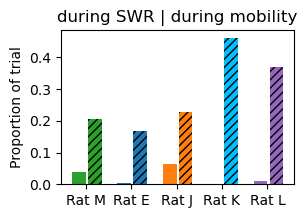

In [20]:
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}

fig, axes = plt.subplots(1, 1, figsize=(3, 2),sharey = True)

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]

annotations = []

animal_ind = 0
for animal in animals:
    ax = plot_one_axis(swr_proportion[animal], theta_proportion[animal], animal_ind, axes, animal)
    animal_ind += 1

axes.set_xticks(np.arange(len(animals))+0.15);
axes.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
axes.set_title("during SWR | during mobility")
axes.set_ylabel("Proportion of trial")

plt.savefig(f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure2/figure2_SWR_proportion.pdf',
            dpi=300,bbox_inches='tight')